# 📊 Notebook 01 — EDA & Data Preprocessing
> **Market Demand Trend Analysis** | *Exploratory Data Analysis*

**Objectives**
- Load and inspect all three raw datasets
- Merge on `job_link`
- Parse and validate date columns
- Explore distributions: job level, type, country, role
- Visualise posting volume over time
- Save a clean merged dataset for downstream notebooks

---

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from utils import (
    set_style, load_postings, load_skills, load_merged,
    add_role_category, build_daily_series,
    savefig, save_plotly, PALETTE, OUT_FIG, OUT_REP
)

set_style()
print('✅ Setup complete')

✅ Setup complete


## 1. Load Raw Datasets

In [2]:
postings = load_postings()
skills   = load_skills()

print(f'📁 Postings : {postings.shape}')
print(f'📁 Skills   : {skills.shape}')

postings.head(3)

📁 Postings : (12217, 15)
📁 Skills   : (12217, 2)


,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
0,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-21 08:08:48.031964+00:00,Finished NER,t,t,f,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite
1,https://www.linkedin.com/jobs/view/principal-s...,2024-01-20 04:02:12.331406+00:00,Finished NER,t,t,f,"Principal Software Engineer, ML Accelerators",Aurora,"San Francisco, CA",2024-01-14,El Cerrito,United States,Set-Key Driver,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/senior-etl-...,2024-01-21 08:08:31.941595+00:00,Finished NER,t,t,f,Senior ETL Data Warehouse Specialist,Adame Services LLC,"New York, NY",2024-01-14,Middletown,United States,Technical Support Specialist,Associate,Onsite


In [3]:
skills.head(3)

,job_link,job_skills
0,https://www.linkedin.com/jobs/view/senior-mach...,"Machine Learning, Programming, Python, Scala, ..."
1,https://www.linkedin.com/jobs/view/principal-s...,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,..."
2,https://www.linkedin.com/jobs/view/senior-etl-...,"ETL, Data Integration, Data Transformation, Da..."


In [4]:
# Data types and nulls
print('=== POSTINGS INFO ===')
print(postings.dtypes)
print('\nNull counts:')
print(postings.isnull().sum())

=== POSTINGS INFO ===
job_link                               str
last_processed_time    datetime64[us, UTC]
last_status                            str
got_summary                            str
got_ner                                str
is_being_worked                        str
job_title                              str
company                                str
job_location                           str
first_seen                  datetime64[us]
search_city                            str
search_country                         str
search_position                        str
job_level                              str
job_type                               str
dtype: object

Null counts:
job_link               0
last_processed_time    0
last_status            0
got_summary            0
got_ner                0
is_being_worked        0
job_title              0
company                0
job_location           1
first_seen             0
search_city            0
search_country         0
searc

## 2. Merge Datasets

In [5]:
df = load_merged(include_summary=False)
df = add_role_category(df, title_col='job_title')

print(f'Merged shape : {df.shape}')
print(f'Date range   : {df["first_seen"].min()} → {df["first_seen"].max()}')
print(f'Null skills  : {df["job_skills"].isna().sum()}')
df.head()

Merged shape : (12217, 17)
Date range   : 2024-01-12 00:00:00 → 2024-01-17 00:00:00


Null skills  : 5


,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type,job_skills,role_category
0,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-21 08:08:48.031964+00:00,Finished NER,t,t,f,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite,"Machine Learning, Programming, Python, Scala, ...",ML Engineer
1,https://www.linkedin.com/jobs/view/principal-s...,2024-01-20 04:02:12.331406+00:00,Finished NER,t,t,f,"Principal Software Engineer, ML Accelerators",Aurora,"San Francisco, CA",2024-01-14,El Cerrito,United States,Set-Key Driver,Mid senior,Onsite,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,...",Other
2,https://www.linkedin.com/jobs/view/senior-etl-...,2024-01-21 08:08:31.941595+00:00,Finished NER,t,t,f,Senior ETL Data Warehouse Specialist,Adame Services LLC,"New York, NY",2024-01-14,Middletown,United States,Technical Support Specialist,Associate,Onsite,"ETL, Data Integration, Data Transformation, Da...",Data Engineer
3,https://www.linkedin.com/jobs/view/senior-data...,2024-01-20 15:30:55.796572+00:00,Finished NER,t,t,f,Senior Data Warehouse Developer / Architect,Morph Enterprise,"Harrisburg, PA",2024-01-12,Lebanon,United States,Architect,Mid senior,Onsite,"Data Lakes, Data Bricks, Azure Data Factory Pi...",Other
4,https://www.linkedin.com/jobs/view/lead-data-e...,2024-01-21 08:08:58.312124+00:00,Finished NER,t,t,f,Lead Data Engineer,Dice,"Plano, TX",2024-01-14,McKinney,United States,Maintenance Data Analyst,Mid senior,Onsite,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S...",Data Engineer


## 3. Missing Values & Duplicates

✅ Saved → C:\Users\victus\Desktop\Repository\Market-Demand-Trend-Analysis\outputs\figures\01_missing_values.png


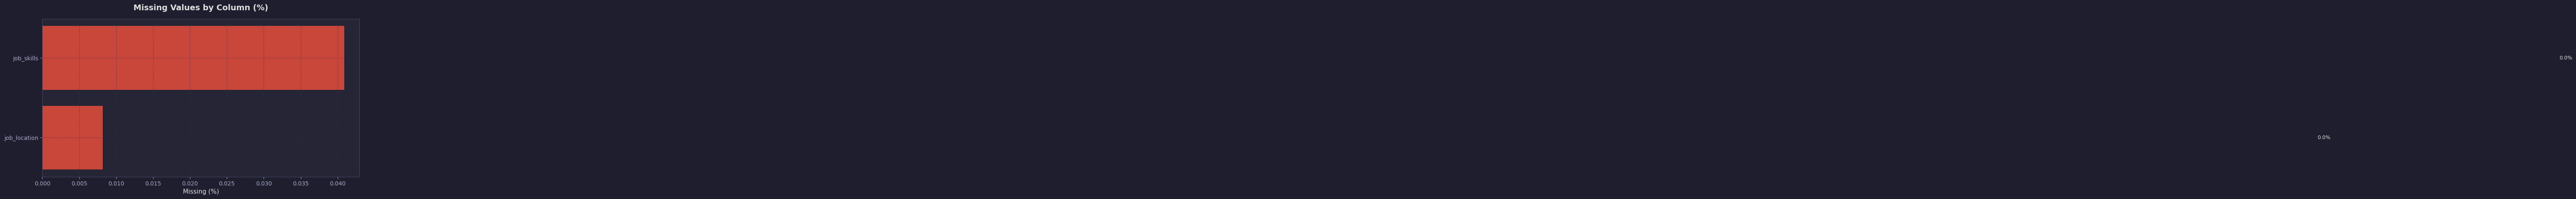

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

bars = ax.barh(missing_pct.index, missing_pct.values,
               color=PALETTE['danger'], alpha=0.85, edgecolor='none')

for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color='#DEDEDE')

ax.set_title('Missing Values by Column (%)', pad=15, fontweight='bold')
ax.set_xlabel('Missing (%)')
ax.invert_yaxis()
plt.tight_layout()
savefig(fig, '01_missing_values')
plt.show()

## 4. Posting Volume Over Time

In [7]:
daily = build_daily_series(df, date_col='first_seen')
print('Daily posting counts:')
print(daily)

Daily posting counts:
2024-01-12    1722
2024-01-13    4946
2024-01-14    3194
2024-01-15     871
2024-01-16    1211
2024-01-17     273
Freq: D, Name: posting_count, dtype: int64


✅ Saved → C:\Users\victus\Desktop\Repository\Market-Demand-Trend-Analysis\outputs\figures\01_daily_posting_volume.png


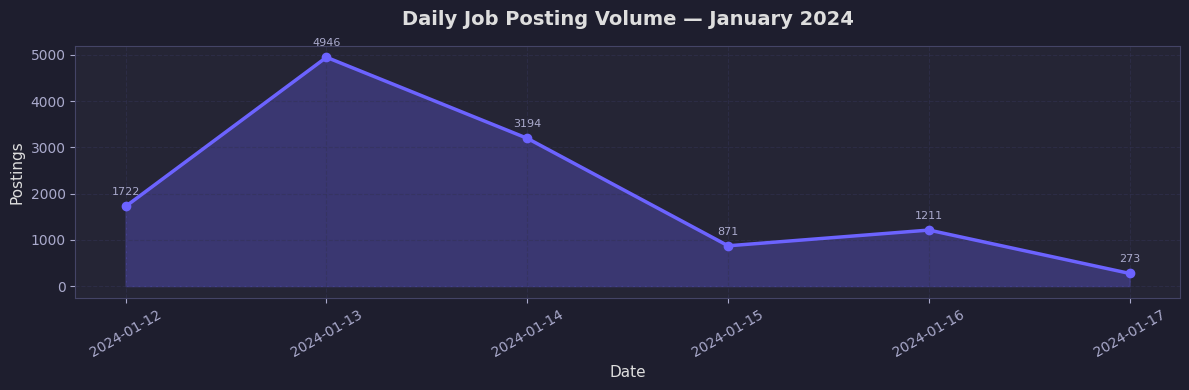

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.fill_between(daily.index, daily.values,
                color=PALETTE['primary'], alpha=0.3)
ax.plot(daily.index, daily.values,
        color=PALETTE['primary'], lw=2.5, marker='o', markersize=6)

for x, y in zip(daily.index, daily.values):
    ax.annotate(str(y), (x, y), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8, color='#AAAACC')

ax.set_title('Daily Job Posting Volume — January 2024', fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Postings')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
savefig(fig, '01_daily_posting_volume')
plt.show()

## 5. Distribution Analysis

✅ Saved → C:\Users\victus\Desktop\Repository\Market-Demand-Trend-Analysis\outputs\figures\01_distribution_overview.png


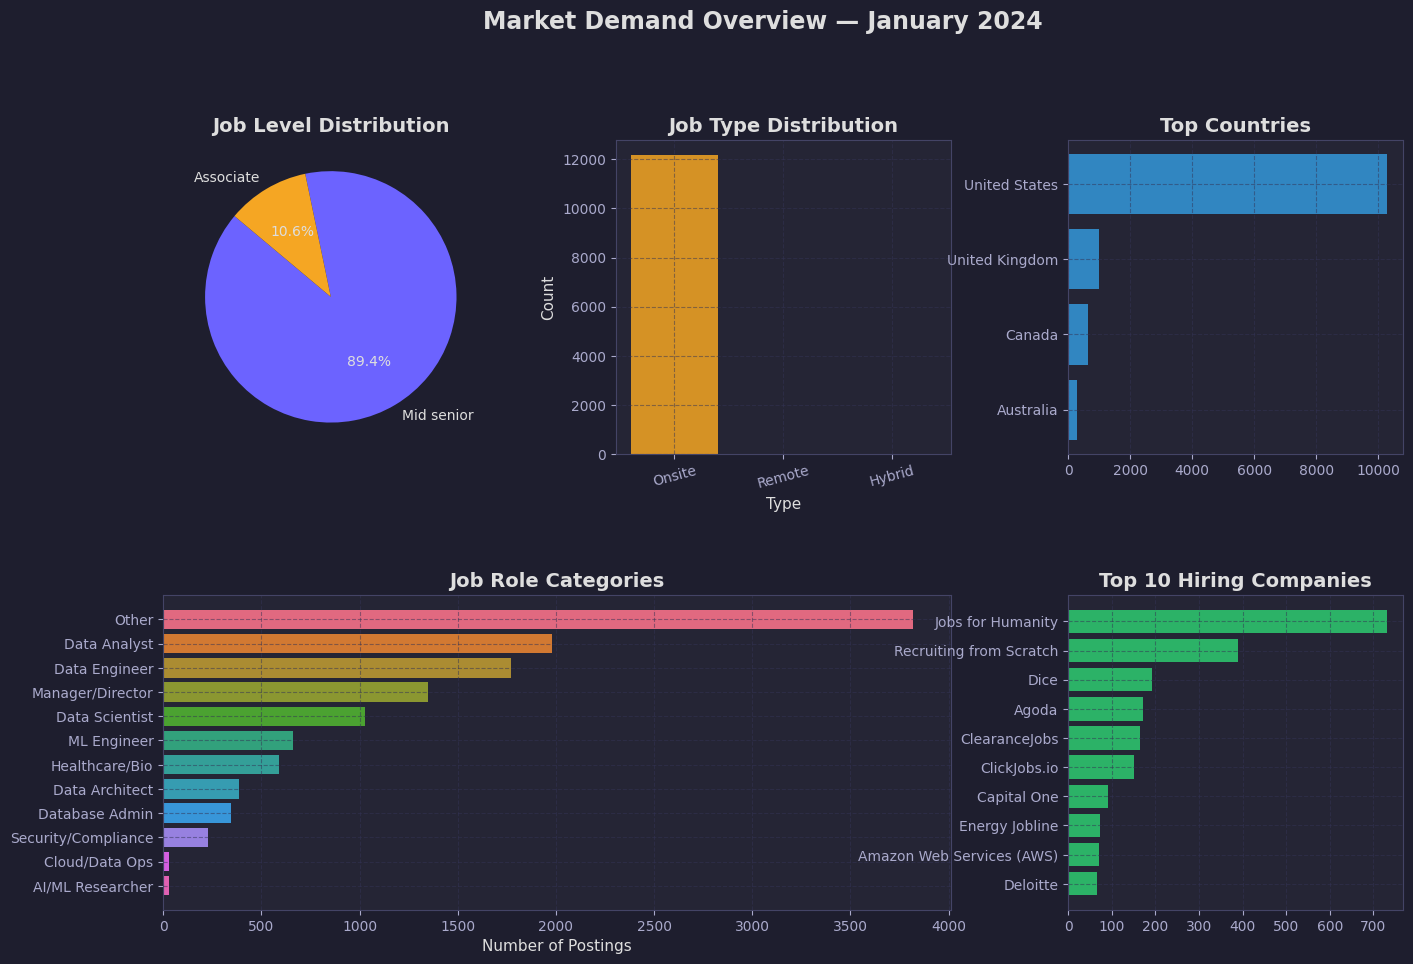

In [9]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Job Level ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
vc  = df['job_level'].value_counts()
ax1.pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=140,
        colors=[PALETTE[k] for k in ['primary','secondary','success','danger','info']][:len(vc)])
ax1.set_title('Job Level Distribution', fontweight='bold')

# ── Job Type ───────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
vc2 = df['job_type'].value_counts()
ax2.bar(vc2.index, vc2.values,
        color=PALETTE['secondary'], alpha=0.85, edgecolor='none')
ax2.set_title('Job Type Distribution', fontweight='bold')
ax2.set_xlabel('Type')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=15)

# ── Country ────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
vc3 = df['search_country'].value_counts().head(8)
ax3.barh(vc3.index, vc3.values, color=PALETTE['info'], alpha=0.85, edgecolor='none')
ax3.set_title('Top Countries', fontweight='bold')
ax3.invert_yaxis()

# ── Role Category ──────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])
vc4 = df['role_category'].value_counts()
colors4 = sns.color_palette('husl', len(vc4))
ax4.barh(vc4.index, vc4.values, color=colors4, alpha=0.9, edgecolor='none')
ax4.invert_yaxis()
ax4.set_title('Job Role Categories', fontweight='bold')
ax4.set_xlabel('Number of Postings')

# ── Top Companies ─────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
vc5 = df['company'].value_counts().head(10)
ax5.barh(vc5.index, vc5.values, color=PALETTE['success'], alpha=0.85, edgecolor='none')
ax5.invert_yaxis()
ax5.set_title('Top 10 Hiring Companies', fontweight='bold')

fig.suptitle('Market Demand Overview — January 2024', fontsize=17, fontweight='bold', y=1.01)
savefig(fig, '01_distribution_overview')
plt.show()

## 6. Geographic Analysis

In [10]:
country_counts = df['search_country'].value_counts().reset_index()
country_counts.columns = ['country', 'postings']

fig = px.choropleth(
    country_counts,
    locations='country',
    locationmode='country names',
    color='postings',
    color_continuous_scale='Viridis',
    title='Job Posting Geographic Distribution',
    template='plotly_dark'
)
fig.update_layout(height=450)
save_plotly(fig, '01_geographic_distribution')
fig.show()

✅ Saved → C:\Users\victus\Desktop\Repository\Market-Demand-Trend-Analysis\outputs\figures\01_geographic_distribution.html


## 7. Role × Date Heatmap

✅ Saved → C:\Users\victus\Desktop\Repository\Market-Demand-Trend-Analysis\outputs\figures\01_role_date_heatmap.png


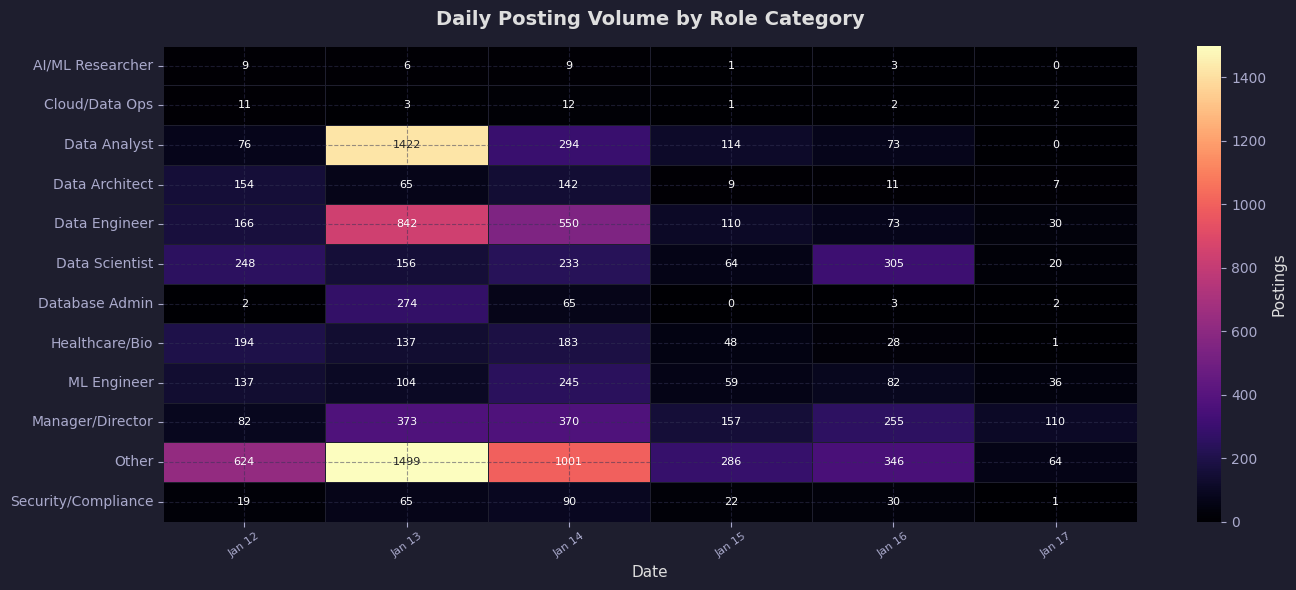

In [11]:
df['date_str'] = df['first_seen'].dt.strftime('%b %d')
pivot = df.pivot_table(index='role_category', columns='date_str',
                       values='job_link', aggfunc='count', fill_value=0)

# sort columns chronologically
col_order = df[['first_seen','date_str']].dropna().drop_duplicates()\
              .sort_values('first_seen')['date_str'].unique()
pivot = pivot.reindex(columns=[c for c in col_order if c in pivot.columns])

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, ax=ax, cmap='magma', linewidths=0.4, linecolor='#1E1E2E',
            annot=True, fmt='d', annot_kws={'size': 8},
            cbar_kws={'label': 'Postings'})
ax.set_title('Daily Posting Volume by Role Category', fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=35, labelsize=8)
plt.tight_layout()
savefig(fig, '01_role_date_heatmap')
plt.show()

## 8. Save Clean Dataset

In [12]:
clean_path = OUT_REP / 'merged_clean.parquet'
df.to_parquet(clean_path, index=False)
print(f'✅ Clean dataset saved → {clean_path}')
print(f'   Shape : {df.shape}')
print(f'   Columns : {list(df.columns)}')

✅ Clean dataset saved → C:\Users\victus\Desktop\Repository\Market-Demand-Trend-Analysis\outputs\reports\merged_clean.parquet
   Shape : (12217, 18)
   Columns : ['job_link', 'last_processed_time', 'last_status', 'got_summary', 'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location', 'first_seen', 'search_city', 'search_country', 'search_position', 'job_level', 'job_type', 'job_skills', 'role_category', 'date_str']


---
## Summary

| Metric | Value |
|---|---|
| Total postings | `df.shape[0]` |
| Date range | Jan 12 – Jan 21, 2024 |
| Countries | `search_country` unique count |
| Role categories identified | 11 |

➡️ **Next: Notebook 02 — Emerging Roles & Skills Analysis**